In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [33]:
df = pd.read_csv("Telecom_Customer_churn.csv")

In [34]:
df.shape

(7043, 21)

In [58]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12


In [35]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [59]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
Tenure_Group           6
dtype: int64

In [36]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [37]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [38]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
#   Step 3: Handle missing values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [40]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())
print("\nMissing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [66]:
print(len(df))

7043


In [41]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"\nRemoved {before - after} duplicate rows.")


Removed 0 duplicate rows.


In [42]:
#%% Step 5: Check for inconsistent data and standardize it
df["Churn"] = df["Churn"].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)

In [43]:
df["SeniorCitizen"] = df["SeniorCitizen"].apply(lambda x: "Yes" if x == 1 else "No")
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
print("\nStandardization done — categorical consistency ensured.")


Standardization done — categorical consistency ensured.


In [44]:
#%% Step 6: Convert columns to correct data types
categorical_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

In [45]:
df[categorical_columns] = df[categorical_columns].astype('category')
print("\nConverted categorical columns to 'category' dtype.")


Converted categorical columns to 'category' dtype.


In [46]:
#%% Step 7: Identify and handle outliers
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before_rows = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after_rows = df.shape[0]
    print(f"Removed {before_rows - after_rows} outliers from '{col}'.")


Removed 0 outliers from 'tenure'.
Removed 0 outliers from 'MonthlyCharges'.
Removed 0 outliers from 'TotalCharges'.


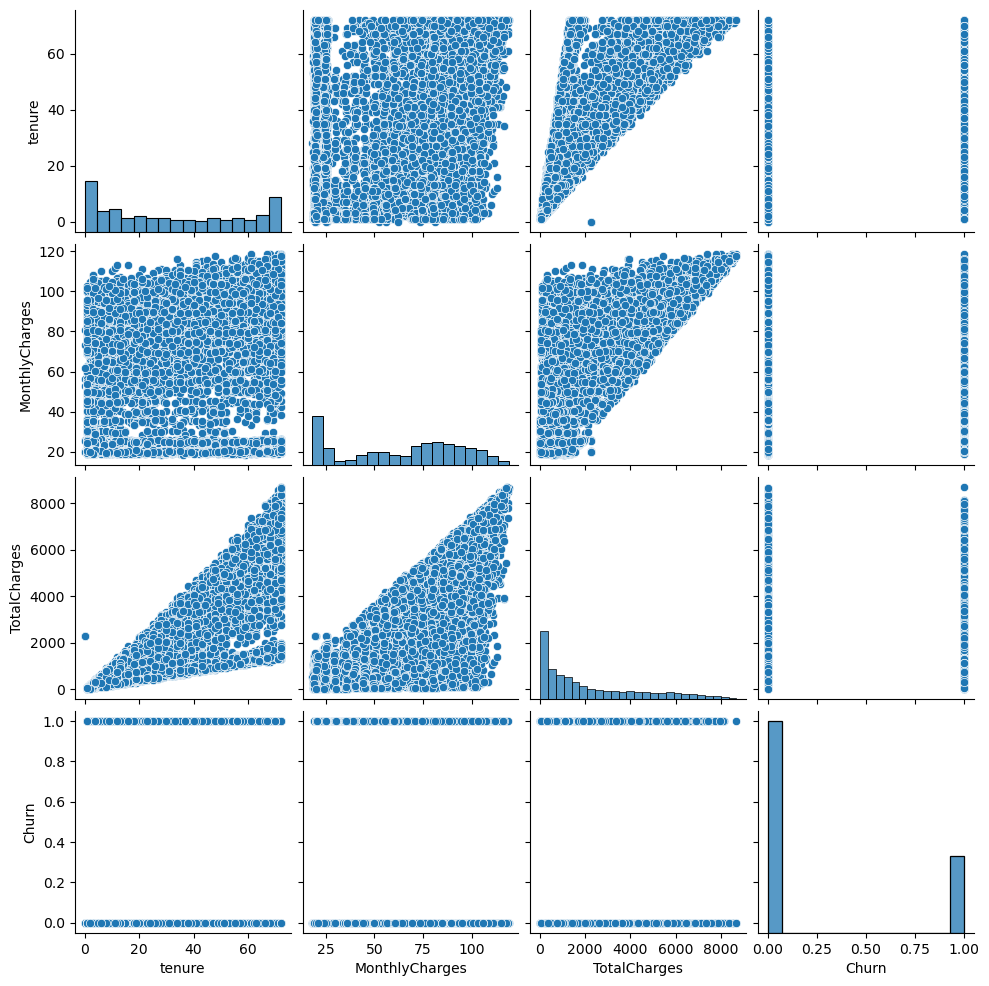

In [65]:
sns.pairplot(df)

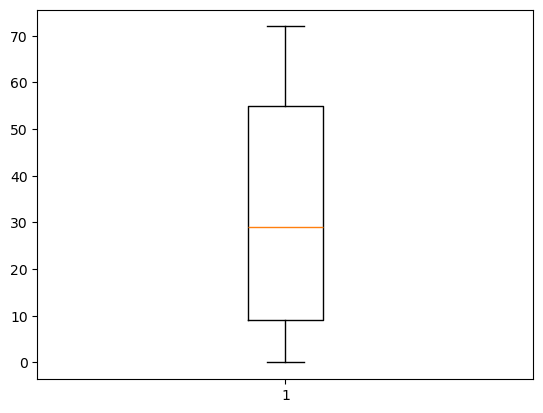

In [61]:

plt.boxplot(df['tenure'])
plt.show()

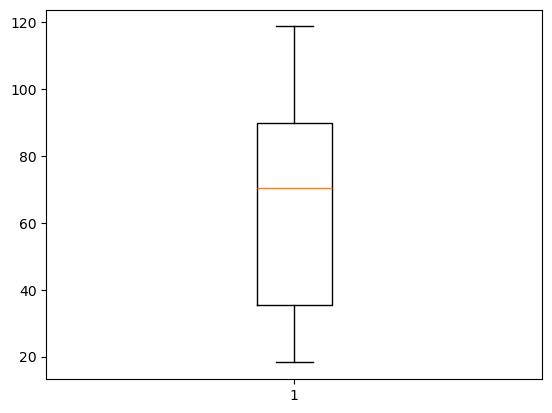

In [62]:

plt.boxplot(df['MonthlyCharges']) 
plt.show()

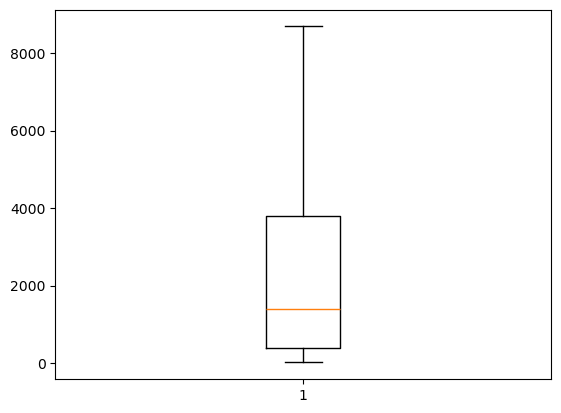

In [67]:

plt.boxplot(df['TotalCharges']) 
plt.show()

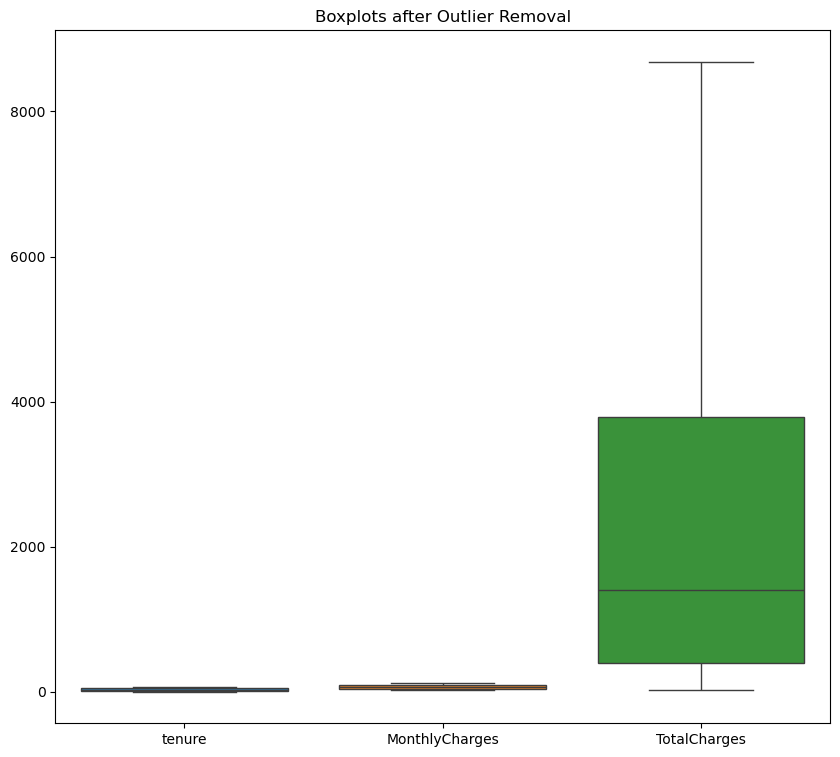

In [68]:
plt.figure(figsize=(10,9))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots after Outlier Removal")
plt.show()

In [48]:
#%% Step 8: Feature Engineering
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)
print("\nNew Feature Created: 'Tenure_Group'")


New Feature Created: 'Tenure_Group'


In [49]:
#%% Step 9: Split dataset into training and testing sets (BEFORE scaling)
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
X_train.shape

(5634, 20)

In [63]:
y_train.shape

(5634,)

In [52]:
X_test.shape

(1409, 20)

In [64]:
y_test.shape

(1409,)

In [53]:
#%% Step 10: Normalize or scale numerical columns (AFTER splitting)
scaler = StandardScaler()

In [54]:
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [55]:
# Fit on training data only
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

In [56]:
# Transform test data using same scaler
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [57]:
#%% Step 11: Export the cleaned dataset
df.to_csv("Cleaned_Telecom_Customer_Churn.csv", index=False)
print("\n✅ Cleaned dataset exported successfully as 'Cleaned_Telecom_Customer_Churn.csv'")


✅ Cleaned dataset exported successfully as 'Cleaned_Telecom_Customer_Churn.csv'
